## TASK 2
### Stochastic Gradient Descent And Cross-Entropy Loss

starting double descent sweep...

width=   8 | params=   6370 | train_err=0.1400 | test_err=0.1922
width=  16 | params=  12730 | train_err=0.1000 | test_err=0.1431
width=  24 | params=  19090 | train_err=0.0910 | test_err=0.1334
width=  32 | params=  25450 | train_err=0.0930 | test_err=0.1383
width=  48 | params=  38170 | train_err=0.0880 | test_err=0.1340
width=  64 | params=  50890 | train_err=0.0910 | test_err=0.1316
width=  96 | params=  76330 | train_err=0.0810 | test_err=0.1327
width= 128 | params= 101770 | train_err=0.0770 | test_err=0.1274
width= 192 | params= 152650 | train_err=0.0810 | test_err=0.1236
width= 256 | params= 203530 | train_err=0.0820 | test_err=0.1278
width= 384 | params= 305290 | train_err=0.0830 | test_err=0.1257
width= 512 | params= 407050 | train_err=0.0800 | test_err=0.1204
width= 768 | params= 610570 | train_err=0.0700 | test_err=0.1189
width=1024 | params= 814090 | train_err=0.0660 | test_err=0.1170
width=2048 | params=1628170 | train_err=0.0560 | test_er

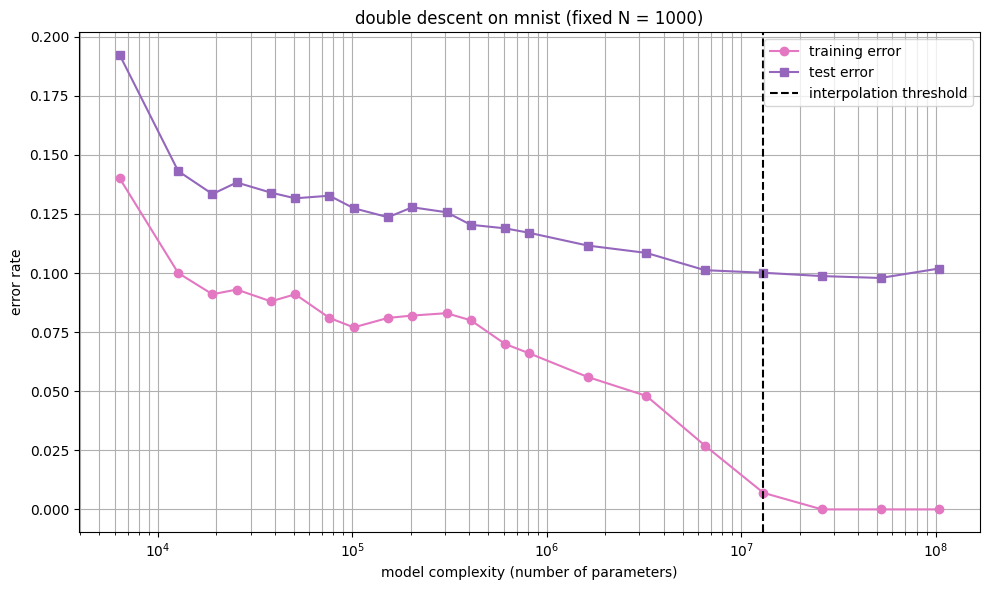

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt


# setup
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
np.random.seed(0)

N_TRAIN = 1000       # fixed training size 
N_EPOCHS = 45       
BATCH_SIZE = 128
LR = 0.01


# model def
class MLP(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, width),
            nn.ReLU(),
            nn.Linear(width, 10)
        )

    def forward(self, x):
        return self.net(x)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# train and evaluating
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

def evaluate(model, loader, criterion):
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0.0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss_sum += criterion(out, y).item()
            pred = out.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    return loss_sum / len(loader), correct / total


# data processing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train = datasets.MNIST("data", train=True, download=True, transform=transform)
test_set = datasets.MNIST("data", train=False, download=True, transform=transform)

indices = torch.randperm(len(full_train))[:N_TRAIN]
train_subset = Subset(full_train, indices)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=512, shuffle=False)

criterion = nn.CrossEntropyLoss()


#  model complexity
widths = [8, 16, 24, 32, 48, 64, 96, 128, 192, 256, 384, 512, 768, 1024, 2048, 4096, 8192, 16384, 32768,65536,131072]

params_list = []
train_err_list = []
test_err_list = []

print("starting double descent sweep...\n")

for w in widths:
    model = MLP(w).to(device)
    optimizer = optim.SGD(model.parameters(), lr=LR)

    for _ in range(N_EPOCHS):
        train_epoch(model, train_loader, optimizer, criterion)

    train_loss, train_acc = evaluate(model, train_loader, criterion)
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    params = count_parameters(model)

    params_list.append(params)
    train_err_list.append(1 - train_acc)
    test_err_list.append(1 - test_acc)

    print(f"width={w:4d} | params={params:7d} | "
          f"train_err={1-train_acc:.4f} | test_err={1-test_acc:.4f}")

# plot double descent
params_arr = np.array(params_list)
train_err = np.array(train_err_list)
test_err = np.array(test_err_list)

threshold = 0.01  # 1% training error

interp_candidates = np.where(train_err < threshold)[0]
interp_idx = interp_candidates[0] if len(interp_candidates) > 0 else len(train_err) - 1
interp_params = params_arr[interp_idx]


plt.figure(figsize=(10, 6))
plt.plot(params_arr, train_err, "o-", color="#e377c2", label="training error")  
plt.plot(params_arr, test_err,  "s-", color="#9467bd", label="test error")     
plt.axvline(interp_params, linestyle="--", color="k",
            label="interpolation threshold")

plt.xscale("log")
plt.xlabel("model complexity (number of parameters)")
plt.ylabel("error rate")
plt.title("double descent on mnist (fixed N = 1000)")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.savefig("double_descent_mnist.png", dpi=300)
plt.show()


#### Extra Plot 

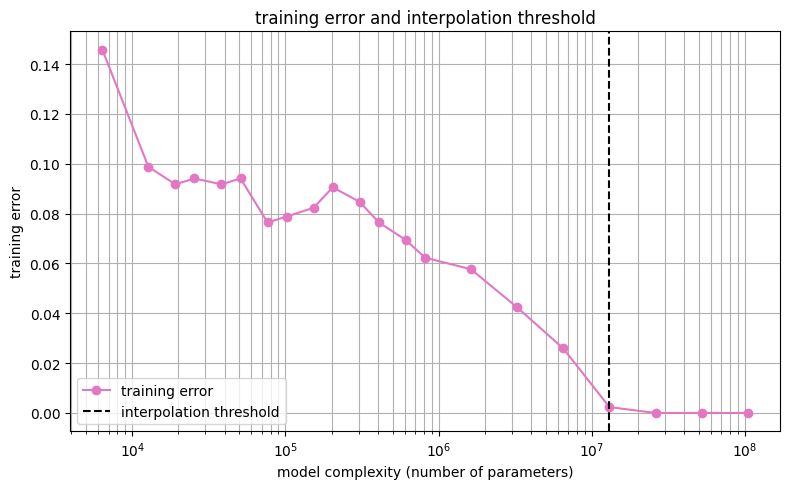

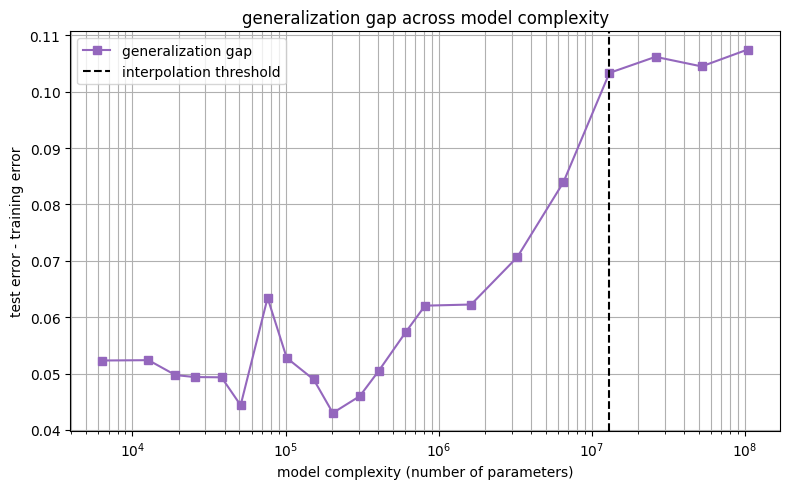

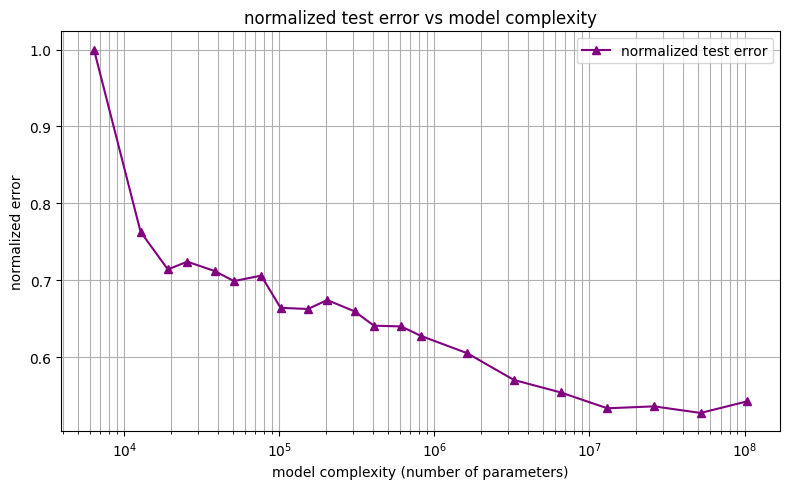

In [6]:
# training error only
plt.figure(figsize=(8, 5))
plt.plot(
    params_arr,
    train_err,
    marker="o",
    linestyle="-",
    color="#e377c2",  
    label="training error"
)
plt.axvline(
    interp_params,
    linestyle="--",
    color="black",
    label="interpolation threshold"
)

plt.xscale("log")
plt.xlabel("model complexity (number of parameters)")
plt.ylabel("training error")
plt.title("training error and interpolation threshold")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.savefig("dd_training_error_only.png", dpi=300)
plt.show()


# test error and training error
generalization_gap = test_err - train_err

plt.figure(figsize=(8, 5))
plt.plot(
    params_arr,
    generalization_gap,
    marker="s",
    linestyle="-",
    color="#9467bd",  # purple
    label="generalization gap"
)
plt.axvline(
    interp_params,
    linestyle="--",
    color="black",
    label="interpolation threshold"
)

plt.xscale("log")
plt.xlabel("model complexity (number of parameters)")
plt.ylabel("test error - training error")
plt.title("generalization gap across model complexity")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.savefig("dd_generalization_gap.png", dpi=300)
plt.show()


# normalized test error 
test_err_norm = test_err / test_err.max()

plt.figure(figsize=(8, 5))
plt.plot(
    params_arr,
    test_err_norm,
    marker="^",
    linestyle="-",
    color="purple",
    label="normalized test error"
)

plt.xscale("log")
plt.xlabel("model complexity (number of parameters)")
plt.ylabel("normalized error")
plt.title("normalized test error vs model complexity")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.savefig("dd_normalized_test_error.png", dpi=300)
plt.show()


#### Full-Batch Training With Mean Squared Error

width=     8 | params=     6370 | train_err=0.5390 | test_err=0.5925
width=    16 | params=    12730 | train_err=0.4250 | test_err=0.4554
width=    32 | params=    25450 | train_err=0.3030 | test_err=0.3287
width=    64 | params=    50890 | train_err=0.1930 | test_err=0.2475
width=   128 | params=   101770 | train_err=0.1720 | test_err=0.2302
width=   256 | params=   203530 | train_err=0.1670 | test_err=0.2313
width=   512 | params=   407050 | train_err=0.1420 | test_err=0.1998
width=  1024 | params=   814090 | train_err=0.1180 | test_err=0.1716
width=  2048 | params=  1628170 | train_err=0.1000 | test_err=0.1557
width=  4096 | params=  3256330 | train_err=0.0900 | test_err=0.1583
width=  8192 | params=  6512650 | train_err=0.5790 | test_err=0.6417
width= 16384 | params= 13025290 | train_err=0.7910 | test_err=0.8133
width= 32768 | params= 26050570 | train_err=0.9020 | test_err=0.9018
width= 65536 | params= 52101130 | train_err=0.9010 | test_err=0.8991
width=131072 | params=104202250 | 

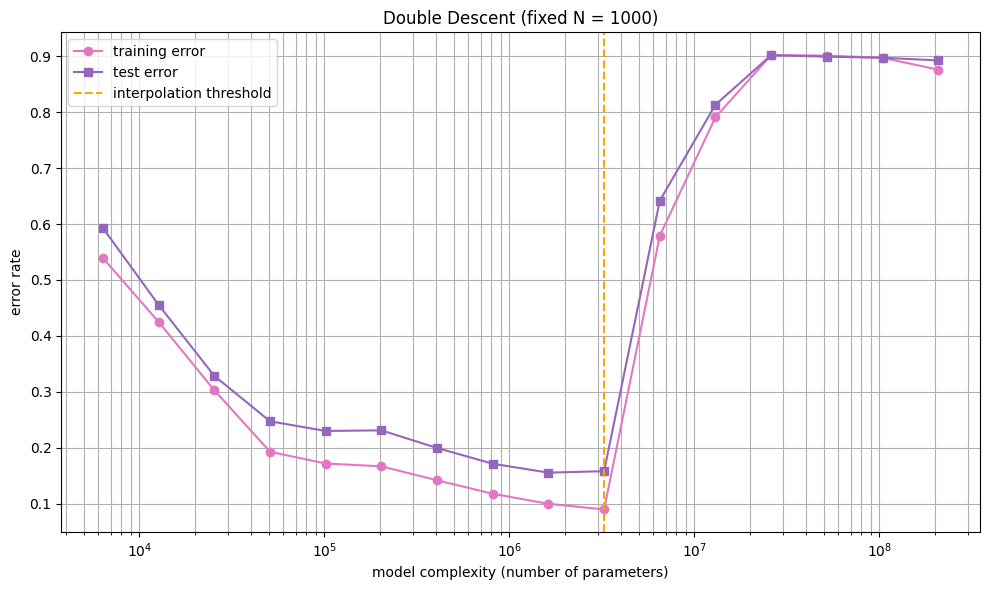

In [10]:

# Setup
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
np.random.seed(0)

N_TRAIN = 1000          # fixed training size 
N_EPOCHS = 80           # long training to reach interpolation
LR = 0.05              
BATCH_SIZE = N_TRAIN    # FULL-BATCH gradient descent

# Model def
class MLP(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, width),
            nn.ReLU(),
            nn.Linear(width, 10)
        )

    def forward(self, x):
        return self.net(x)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Training and evaluation
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total


# Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train = datasets.MNIST("data", train=True, download=True, transform=transform)
test_set = datasets.MNIST("data", train=False, download=True, transform=transform)

indices = torch.randperm(len(full_train))[:N_TRAIN]
train_subset = Subset(full_train, indices)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=512, shuffle=False)


# Loss: MSE (no implicit softmax bias)
criterion = nn.MSELoss()

def one_hot(labels, num_classes=10):
    return torch.eye(num_classes, device=labels.device)[labels]

# model complexity
widths = [
    8, 16, 32, 64, 128, 256,
    512, 1024, 2048, 4096,
    8192, 16384,32768,65536,131072,262144
]

params_list = []
train_err_list = []
test_err_list = []

for w in widths:
    model = MLP(w).to(device)
    optimizer = optim.SGD(model.parameters(), lr=LR)  # no momentum

    for _ in range(N_EPOCHS):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            y_oh = one_hot(y)
            optimizer.zero_grad()
            loss = criterion(model(x), y_oh)
            loss.backward()
            optimizer.step()

    train_acc = evaluate(model, train_loader)
    test_acc = evaluate(model, test_loader)

    params = count_parameters(model)

    params_list.append(params)
    train_err_list.append(1 - train_acc)
    test_err_list.append(1 - test_acc)

    print(f"width={w:6d} | params={params:9d} | "
          f"train_err={1-train_acc:.4f} | test_err={1-test_acc:.4f}")


# near-zero training error
params_arr = np.array(params_list)
train_err = np.array(train_err_list)
test_err = np.array(test_err_list)

# interpolation threshold: sufficiently small training error
# interpolation threshold approximated by minimum training error
interp_idx = np.argmin(train_err)
interp_params = params_arr[interp_idx]


# Plot
plt.figure(figsize=(10, 6))
plt.plot(params_arr, train_err, "o-", color="#e377c2", label="training error")
plt.plot(params_arr, test_err,  "s-", color="#9467bd", label="test error")
plt.axvline(interp_params, linestyle="--", color="orange",
            label="interpolation threshold")

plt.xscale("log")
plt.xlabel("model complexity (number of parameters)")
plt.ylabel("error rate")
plt.title(f"Double Descent (fixed N = {N_TRAIN})")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.savefig("double_descent_mnist_mse_fullbatch.png", dpi=300)
plt.show()
